### STUDENT HEALTH ANALYSIS PROJECT

In [33]:
## General Purpose
import warnings
from itertools import combinations
from copy import deepcopy

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option("display.max_columns", None)

In [34]:
df = pd.read_csv("data/test.csv")
df

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,690088,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,690089,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,690090,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,690091,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,690092,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295748,985836,7.13,77.5,22.20,2221.0,13981.0,65.6,2.17,balanced,low,average,active,occasional,other
295749,985837,6.25,69.5,20.93,2242.0,2370.0,23.6,1.98,balanced,NaN,average,moderate,yes,female
295750,985838,NaN,77.0,23.62,2111.0,7647.0,25.1,2.18,veg,high,average,sedentary,no,other
295751,985839,7.25,66.3,21.47,2009.0,4672.0,25.1,2.02,veg,high,poor,moderate,no,female


In [106]:
student_data = df.drop('id', axis=1).copy()
student_data.head(5)

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,5.35,64.9,23.48,2745.0,14167.0,59.5,1.86,veg,high,poor,active,occasional,male
1,NaN,83.1,22.42,1773.0,6801.0,24.5,2.40,balanced,high,poor,sedentary,yes,other
2,6.68,59.7,24.14,3040.0,13250.0,48.5,2.76,balanced,medium,poor,active,no,NaN
3,7.13,78.5,26.26,2494.0,6331.0,56.9,2.34,veg,low,good,moderate,yes,other
4,5.49,77.7,23.29,1828.0,13894.0,39.4,2.45,veg,high,average,active,occasional,other


In [107]:
student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   sleep_duration           263182 non-null  float64
 1   heart_rate               292396 non-null  float64
 2   bmi                      289797 non-null  float64
 3   calorie_expenditure      273101 non-null  float64
 4   step_count               289789 non-null  float64
 5   exercise_duration        292795 non-null  float64
 6   water_intake             277120 non-null  float64
 7   diet_type                292795 non-null  str    
 8   stress_level             260263 non-null  str    
 9   sleep_quality            270754 non-null  str    
 10  physical_activity_level  280058 non-null  str    
 11  smoking_alcohol          283504 non-null  str    
 12  gender                   286593 non-null  str    
dtypes: float64(7), str(6)
memory usage: 29.3 MB


In [108]:
student_data.shape

(295753, 13)

In [109]:
student_data.isna().sum() / len(student_data) * 100

sleep_duration             11.012906
heart_rate                  1.135069
bmi                         2.013843
calorie_expenditure         7.659094
step_count                  2.016548
exercise_duration           1.000159
water_intake                6.300190
diet_type                   1.000159
stress_level               11.999878
sleep_quality               8.452662
physical_activity_level     5.306793
smoking_alcohol             4.141632
gender                      3.097179
dtype: float64

##### Setting up outlier detection

In [112]:
from pprint import pprint

for col in student_data.select_dtypes(exclude=str):
    mean = student_data[col].mean()
    st_dev = student_data[col].std()
    
    # Store clean floats in your dictionary
    new_col[col] = float(mean), float(deviation)
    
    ### Outlier definition
    outlier_threasold =  st_dev * 3
    print(f'--- {col} outlier ---')
    print(outlier_threasold)
    
    
    upper_limit = mean + outlier_threasold
    lower_limit = mean - outlier_threasold
    
    ## Getting outlier
    outlier_numbers = (student_data[col] < lower_limit) | (student_data[col] > upper_limit)
    print(f'Number of outliers found {outlier_numbers.sum()}\n')
    
pprint(new_col)    
    

--- sleep_duration outlier ---
3.6491078148794767
Number of outliers found 411

--- heart_rate outlier ---
24.34535533915013
Number of outliers found 397

--- bmi outlier ---
7.436125192802905
Number of outliers found 490

--- calorie_expenditure outlier ---
1043.4502827454046
Number of outliers found 177

--- step_count outlier ---
11773.94003049261
Number of outliers found 0

--- exercise_duration outlier ---
44.13354088204907
Number of outliers found 18

--- water_intake outlier ---
1.5563124280258969
Number of outliers found 1595

{'bmi': (22.984661159363277, 0.5187708093419656),
 'calorie_expenditure': (2225.5149413586914, 0.5187708093419656),
 'exercise_duration': (38.796712375552865, 0.5187708093419656),
 'heart_rate': (75.07955956989835, 0.5187708093419656),
 'sleep_duration': (6.993516843857103, 0.5187708093419656),
 'step_count': (8626.630524278009, 0.5187708093419656),
 'water_intake': (2.1915079748845265, 0.5187708093419656)}


### Visualizing the outliers

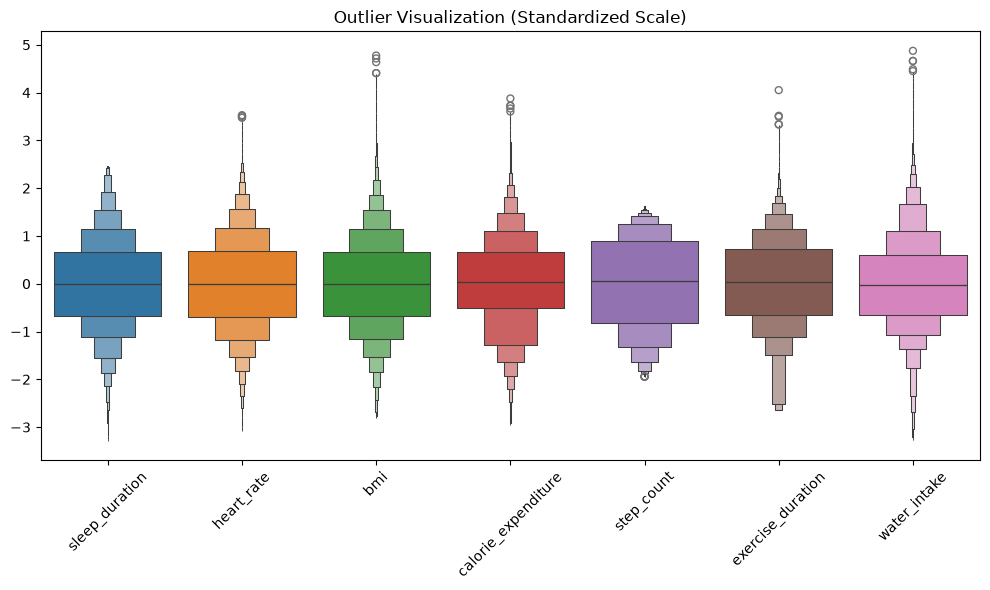

In [ ]:
## Creating the boxplot
num_data = student_data.select_dtypes(exclude=str)

standardized_data = (num_data - num_data.mean() ) / num_data.std()


plt.figure(figsize=(10, 6))
sns.boxenplot(data=standardized_data)
plt.title("Outlier Visualization (Standardized Scale)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()